# Statistical Analysis of PM2.5 Air Pollution Across Major Indian Cities

## 1. Project Overview

This project analyzes PM2.5 air pollution across six major Indian metropolitan areas using continuous ambient air-quality monitoring data distributed through OpenAQ and originating from India's monitoring network (CPCB - Central Pollution Control Board).

The analysis covers the period from March 1, 2025 through August 31, 2026 and includes monitoring stations from:

- Bengaluru
- Chennai
- Delhi
- Hyderabad
- Kolkata
- Mumbai, including Navi Mumbai

The primary analysis cohort contains 86 monitoring stations selected based on temporal availability and measurement completeness. A stricter 71-station cohort is retained for sensitivity analysis.

The objective is to use statistical analysis to examine how PM2.5 concentrations vary across cities, seasons, stations, and comparable time periods.

### Research Questions

This analysis addresses the following questions:

1. How do PM2.5 concentrations differ across the six metropolitan areas?
2. How does PM2.5 vary across meteorological seasons?
3. Does the seasonal pattern differ by metropolitan area?
4. Did PM2.5 concentrations change between March–August 2025 and March–August 2026?
5. How much variation exists between monitoring stations within the same metropolitan area?
6. Are observed differences statistically significant and practically meaningful?

The analysis uses multiple levels of aggregation depending on the research question. Station-day observations are used to examine within-city station variability and data coverage. For primary comparisons between metropolitan areas, station-day observations are further aggregated to **city-day** summaries so that cities with larger monitoring networks do not receive disproportionate statistical weight simply because they contribute more stations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [2]:
DATA_DIR = Path("data/processed")
FIGURES_DIR = Path("figures")

DAILY_DATA_PATH = DATA_DIR / "analysis_daily_station.parquet"
STATIONS_PATH = DATA_DIR / "analysis_stations.csv"
PREPROCESSING_SUMMARY_PATH = DATA_DIR / "preprocessing_summary.json"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [3]:
daily = pd.read_parquet(DAILY_DATA_PATH)
stations = pd.read_csv(STATIONS_PATH)

print(f"Daily station observations: {len(daily):,}")
print(f"Monitoring stations: {daily['location_id'].nunique():,}")
print(f"Metropolitan areas: {daily['metro'].nunique():,}")
print(
    f"Date range: "
    f"{daily['date_local'].min().date()} to "
    f"{daily['date_local'].max().date()}"
)

daily.head()

Daily station observations: 34,669
Monitoring stations: 86
Metropolitan areas: 6
Date range: 2025-03-01 to 2026-08-31


,location_id,station_name,metro,sensitivity_eligible,date_local,pm25_mean,pm25_median,valid_hour_count,valid_15min_count,hour_coverage_pct,year,month,month_name,season,day_of_week,is_weekend
0,17,"R K Puram, Delhi - DPCC",Delhi,True,2025-03-01,60.24,57.00,21,81,87.50,2025,3,March,Pre-monsoon,Saturday,True
1,17,"R K Puram, Delhi - DPCC",Delhi,True,2025-03-04,49.00,47.00,23,88,95.83,2025,3,March,Pre-monsoon,Tuesday,False
2,17,"R K Puram, Delhi - DPCC",Delhi,True,2025-03-05,28.77,29.00,22,85,91.67,2025,3,March,Pre-monsoon,Wednesday,False
3,17,"R K Puram, Delhi - DPCC",Delhi,True,2025-03-06,53.35,50.00,23,88,95.83,2025,3,March,Pre-monsoon,Thursday,False
4,17,"R K Puram, Delhi - DPCC",Delhi,True,2025-03-07,87.00,85.00,23,92,95.83,2025,3,March,Pre-monsoon,Friday,False


In [4]:
assert daily["location_id"].nunique() == 86
assert daily["metro"].nunique() == 6
assert daily["pm25_mean"].notna().all()
assert (daily["pm25_mean"] >= 0).all()
assert (daily["pm25_mean"] < 1000).all()

print("Basic dataset validation passed.")

Basic dataset validation passed.


In [5]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 34669 entries, 0 to 34668
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   location_id           34669 non-null  int64         
 1   station_name          34669 non-null  str           
 2   metro                 34669 non-null  str           
 3   sensitivity_eligible  34669 non-null  bool          
 4   date_local            34669 non-null  datetime64[ms]
 5   pm25_mean             34669 non-null  float64       
 6   pm25_median           34669 non-null  float64       
 7   valid_hour_count      34669 non-null  int64         
 8   valid_15min_count     34669 non-null  int64         
 9   hour_coverage_pct     34669 non-null  float64       
 10  year                  34669 non-null  int32         
 11  month                 34669 non-null  int32         
 12  month_name            34669 non-null  str           
 13  season                34669

In [6]:
daily[
    [
        "pm25_mean",
        "pm25_median",
        "valid_hour_count",
        "valid_15min_count",
        "hour_coverage_pct",
    ]
].describe()

,pm25_mean,pm25_median,valid_hour_count,valid_15min_count,hour_coverage_pct
count,"34,669.00","34,669.00","34,669.00","34,669.00","34,669.00"
mean,55.46,53.08,21.64,83.69,90.15
std,58.03,58.31,1.53,7.19,6.36
min,0.00,0.00,18.00,54.00,75.00
25%,22.83,21.54,21.00,79.00,87.50
50%,37.16,35.05,22.00,86.00,91.67
75%,64.58,61.00,23.00,90.00,95.83
max,985.00,985.00,24.00,96.00,100.00


In [7]:
metro_summary = (
    daily
        .groupby("metro", observed=True)
        .agg(
            stations=("location_id", "nunique"),
            station_days=("location_id", "size"),
            first_date=("date_local", "min"),
            last_date=("date_local", "max"),
        )
        .sort_index()
)

metro_summary

,stations,station_days,first_date,last_date
metro,,,,
Bengaluru,5,1755,2025-03-01,2026-08-31
Chennai,6,2492,2025-03-01,2026-08-31
Delhi,36,15350,2025-03-01,2026-08-31
Hyderabad,13,4662,2025-03-01,2026-08-31
Kolkata,6,2612,2025-03-01,2026-08-31
Mumbai,20,7798,2025-03-01,2026-08-31


## 2. Data Quality and Preprocessing

The source monitoring data consisted of approximately 15-minute PM2.5 measurements. Before statistical analysis, observations were screened for data availability, station coverage, invalid measurement values, and daily completeness.

The original source files were preserved unchanged. Cleaning and aggregation were performed in a reproducible preprocessing pipeline, with the resulting analysis datasets stored separately from the raw measurements.

In [8]:
import json

with PREPROCESSING_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    preprocessing = json.load(file)

pd.Series(preprocessing, name="value").to_frame()

,value
raw_measurement_rows,"3,477,273.00"
missing_value_rows,0.00
missing_datetime_rows,0.00
negative_value_rows,"2,861.00"
upper_extreme_rows,"4,279.00"
zero_value_rows_retained,"24,711.00"
removed_rows,"7,140.00"
removed_pct,0.21
valid_measurement_rows,"3,470,133.00"
hourly_rows,"865,921.00"


### Measurement Cleaning

The primary cohort contained 3,477,273 raw PM2.5 measurements. Exploratory quality checks identified negative measurements and a small number of extreme values associated with obvious sentinel, clipping, or data-corruption patterns.

A conservative cleaning policy was therefore applied:

- Negative PM2.5 measurements were excluded.
- Measurements greater than or equal to 1,000 µg/m³ were excluded as anomalous values for this analysis.
- Zero and low positive measurements were retained rather than automatically treated as missing.
- Raw source measurements were not overwritten.

The cleaning process removed 7,140 observations, representing approximately 0.21% of the raw measurements, leaving 3,470,133 valid 15-minute observations.

### Temporal Aggregation and Completeness

Valid 15-minute measurements were first aggregated to station-hour means. An hourly value was retained only when at least three of the four expected 15-minute observations were available.

Station-hour values were then aggregated to station-day summaries. A station-day was retained only when at least 18 of the expected 24 hourly observations were available, corresponding to a minimum daily coverage of 75%.

After these requirements were applied, the analysis dataset contained 34,669 valid station-day observations.

In [9]:
metro_coverage = (
    daily
        .groupby("metro", observed=True)
        .agg(
            stations=("location_id", "nunique"),
            station_days=("location_id", "size"),
            mean_hour_coverage_pct=("hour_coverage_pct", "mean"),
    )
)

metro_coverage

,stations,station_days,mean_hour_coverage_pct
metro,,,
Bengaluru,5,1755,89.53
Chennai,6,2492,90.64
Delhi,36,15350,90.26
Hyderabad,13,4662,89.55
Kolkata,6,2612,90.85
Mumbai,20,7798,90.06


The monitoring network is unbalanced across metropolitan areas. Delhi contributes the largest number of stations and station-days, while Bengaluru contributes the fewest. This reflects differences in monitoring-network size and data availability rather than an intentionally balanced sampling design.

For this reason, primary city-level comparisons later in the analysis use one aggregated observation per city and day. Station-level observations are retained for analyses specifically examining within-city variability.

## 3. City-Day Analysis Dataset

The monitoring network contains substantially different numbers of stations across metropolitan areas. Directly comparing all station-day observations would therefore give cities with larger monitoring networks, particularly Delhi, greater influence in city-level analyses.

To create a more comparable unit of analysis, station-day PM2.5 values are aggregated to one **city-day** observation for each metropolitan area and calendar date. Each reporting station contributes equally to the city-day summary.

The number and percentage of primary-cohort stations reporting on each day are retained as coverage indicators. These coverage measures are examined before deciding whether any city-days require exclusion.

In [10]:
primary_station_counts = (
    stations.loc[stations["primary_eligible"], ["location_id", "metro"]]
        .groupby("metro",observed=True)
        .agg(expected_stations=("location_id", "nunique"))
        .reset_index()
)

primary_station_counts

,metro,expected_stations
0,Bengaluru,5
1,Chennai,6
2,Delhi,36
3,Hyderabad,13
4,Kolkata,6
5,Mumbai,20


In [11]:
city_day = (
    daily
        .groupby(
            ["metro", "date_local"],
            observed=True,
            as_index=False
        )
        .agg(
            pm25_mean=("pm25_mean", "mean"),
            pm25_median=("pm25_mean", "median"),
            reporting_stations=("location_id", "nunique")
        )
)

city_day = city_day.merge(
    primary_station_counts,
    on="metro",
    how="left",
    validate="many_to_one"
)

city_day["station_coverage_pct"] = city_day["reporting_stations"] / city_day["expected_stations"] * 100

city_day.head()

,metro,date_local,pm25_mean,pm25_median,reporting_stations,expected_stations,station_coverage_pct
0,Bengaluru,2025-03-01,22.11,21.76,5,5,100.00
1,Bengaluru,2025-03-02,20.61,19.37,5,5,100.00
2,Bengaluru,2025-03-03,26.84,27.09,4,5,80.00
3,Bengaluru,2025-03-04,31.20,30.49,5,5,100.00
4,Bengaluru,2025-03-05,39.61,39.91,5,5,100.00


In [12]:
assert not city_day.duplicated(subset=["metro", "date_local"]).any()

assert city_day["pm25_mean"].notna().all()
assert city_day["reporting_stations"].ge(1).all()
assert city_day["station_coverage_pct"].le(100).all()

print(f"City-day observations: {len(city_day):,}")
print(f"Unique dates: {city_day['date_local'].nunique():,}")
print(
    f"Possible city-days: "
    f"{city_day['date_local'].nunique() * city_day['metro'].nunique():,}"
)

City-day observations: 2,957
Unique dates: 499
Possible city-days: 2,994


In [13]:
city_day_coverage = (
    city_day.groupby(
        "metro",
        observed=True,
    )
    .agg(
        city_days=("date_local", "size"),
        min_reporting_stations=("reporting_stations", "min"),
        median_reporting_stations=("reporting_stations", "median"),
        max_reporting_stations=("reporting_stations", "max"),
        min_station_coverage_pct=("station_coverage_pct", "min"),
        median_station_coverage_pct=("station_coverage_pct", "median"),
        mean_station_coverage_pct=("station_coverage_pct", "mean"),
    )
)

city_day_coverage

,city_days,min_reporting_stations,median_reporting_stations,max_reporting_stations,min_station_coverage_pct,median_station_coverage_pct,mean_station_coverage_pct
metro,,,,,,,
Bengaluru,491,1,4.00,5,20.00,80.00,71.49
Chennai,492,1,5.00,6,16.67,83.33,84.42
Delhi,499,1,32.00,36,2.78,88.89,85.45
Hyderabad,494,2,10.00,13,15.38,76.92,72.59
Kolkata,487,1,6.00,6,16.67,100.00,89.39
Mumbai,494,1,16.00,20,5.00,80.00,78.93


In [14]:
city_day[["reporting_stations", "station_coverage_pct"]].describe()

,reporting_stations,station_coverage_pct
count,"2,957.00","2,957.00"
mean,11.72,80.37
std,9.87,18.51
min,1.00,2.78
25%,5.00,70.00
50%,6.00,83.33
75%,16.00,95.00
max,36.00,100.00


In [15]:
cities_per_date = (
    city_day
        .groupby("date_local")["metro"]
        .nunique()
)

print(f"Dates represented by all six metros: {(cities_per_date == 6).sum():,}")

print(f"Dates with fewer than six metros: {(cities_per_date < 6).sum():,}")

cities_per_date.value_counts().sort_index()

Dates represented by all six metros: 484
Dates with fewer than six metros: 15


metro
1      4
2      1
4      3
5      7
6    484
Name: count, dtype: int64

In [16]:
coverage_thresholds = [25, 50, 60, 70, 75]

coverage_sensitivity = pd.DataFrame(
    {
        "threshold_pct": coverage_thresholds,
        "city_days_retained": [
            (city_day["station_coverage_pct"] >= threshold).sum()
            for threshold in coverage_thresholds
        ],
    }
)

coverage_sensitivity["retained_pct"] = (
    coverage_sensitivity["city_days_retained"]
    / len(city_day)
    * 100
)

coverage_sensitivity

,threshold_pct,city_days_retained,retained_pct
0,25,2887,97.63
1,50,2765,93.51
2,60,2667,90.19
3,70,2220,75.08
4,75,2177,73.62


In [17]:
coverage_by_metro = pd.concat(
    [
        (
            city_day.assign(
                meets_threshold=(
                    city_day["station_coverage_pct"] >= threshold
                )
            )
            .groupby(
                "metro",
                observed=True,
            )["meets_threshold"]
            .sum()
            .rename(f">={threshold}%")
        )
        for threshold in coverage_thresholds
    ],
    axis=1,
)

coverage_by_metro

,>=25%,>=50%,>=60%,>=70%,>=75%
metro,,,,,
Bengaluru,457,399,399,282,282
Chennai,488,483,459,371,371
Delhi,492,482,473,454,448
Hyderabad,483,454,419,275,275
Kolkata,482,477,465,429,429
Mumbai,485,470,452,409,372


In [18]:
low_coverage_days = (
    city_day.loc[
        city_day["station_coverage_pct"] < 50,
        [
            "metro",
            "date_local",
            "reporting_stations",
            "expected_stations",
            "station_coverage_pct",
        ],
    ]
    .sort_values(
        [
            "date_local",
            "metro",
        ]
    )
)

print(f"City-days below 50% station coverage: {len(low_coverage_days):,}")

low_coverage_days.head(20)

City-days below 50% station coverage: 192


,metro,date_local,reporting_stations,expected_stations,station_coverage_pct
2487,Mumbai,2025-03-25,9,20,45.00
31,Bengaluru,2025-04-01,2,5,40.00
1516,Hyderabad,2025-04-04,6,13,46.15
1517,Hyderabad,2025-04-05,6,13,46.15
37,Bengaluru,2025-04-07,1,5,20.00
1519,Hyderabad,2025-04-07,5,13,38.46
38,Bengaluru,2025-04-08,1,5,20.00
61,Bengaluru,2025-05-07,2,5,40.00
2524,Mumbai,2025-05-07,4,20,20.00
1544,Hyderabad,2025-05-08,6,13,46.15


### City-Day Coverage Requirement

City-day station coverage varied across the monitoring network. Although median coverage was generally high, some city-days were represented by only a small fraction of the eligible monitoring stations.

A minimum station-coverage requirement of **50%** was selected for the primary city-level analysis. This threshold retains 2,765 of the 2,957 available city-day observations (93.51%) while excluding days with particularly weak spatial representation.

Higher thresholds were considered but would substantially reduce the available data, particularly for Bengaluru and Hyderabad. Because station-days had already been required to meet a 75% within-day temporal completeness threshold, the 50% city-level requirement provides an additional spatial-coverage safeguard without unnecessarily discarding otherwise usable observations.

In [19]:
CITY_DAY_COVERAGE_THRESHOLD = 50

city_day_filtered = (
    city_day.loc[
        city_day["station_coverage_pct"]
        >= CITY_DAY_COVERAGE_THRESHOLD
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Eligible city-days: "
    f"{len(city_day_filtered):,}"
)

print(
    f"City-days excluded: "
    f"{len(city_day) - len(city_day_filtered):,}"
)

Eligible city-days: 2,765
City-days excluded: 192


In [20]:
eligible_cities_per_date = (
    city_day_filtered.groupby(
        "date_local"
    )["metro"]
    .nunique()
)

balanced_dates = eligible_cities_per_date[
    eligible_cities_per_date == 6
].index

city_day_balanced = (
    city_day_filtered[
        city_day_filtered["date_local"]
        .isin(balanced_dates)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Balanced dates: "
    f"{len(balanced_dates):,}"
)

print(
    f"Balanced city-day observations: "
    f"{len(city_day_balanced):,}"
)

Balanced dates: 375
Balanced city-day observations: 2,250


In [21]:
assert (
    city_day_balanced
    .groupby("date_local")["metro"]
    .nunique()
    .eq(6)
    .all()
)

assert len(city_day_balanced) == (
    len(balanced_dates) * 6
)

print("Balanced six-city panel validation passed.")

Balanced six-city panel validation passed.


In [22]:
city_day_balanced["year"] = (
    city_day_balanced["date_local"].dt.year
)

city_day_balanced["month"] = (
    city_day_balanced["date_local"].dt.month
)

city_day_balanced["month_name"] = (
    city_day_balanced["date_local"].dt.month_name()
)


def get_season(month):
    """Map a calendar month to its meteorological season.

    Parameters
    ----------
    month : int
        Calendar month from 1 through 12.

    Returns
    -------
    str
        Meteorological season name.
    """
    if month in (1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Pre-monsoon"
    if month in (6, 7, 8, 9):
        return "Southwest monsoon"
    return "Post-monsoon"


city_day_balanced["season"] = (
    city_day_balanced["month"]
    .apply(get_season)
)

city_day_balanced.head()

,metro,date_local,pm25_mean,pm25_median,reporting_stations,expected_stations,station_coverage_pct,year,month,month_name,season
0,Bengaluru,2025-03-01,22.11,21.76,5,5,100.00,2025,3,March,Pre-monsoon
1,Bengaluru,2025-03-02,20.61,19.37,5,5,100.00,2025,3,March,Pre-monsoon
2,Bengaluru,2025-03-03,26.84,27.09,4,5,80.00,2025,3,March,Pre-monsoon
3,Bengaluru,2025-03-04,31.20,30.49,5,5,100.00,2025,3,March,Pre-monsoon
4,Bengaluru,2025-03-05,39.61,39.91,5,5,100.00,2025,3,March,Pre-monsoon


For direct comparisons between metropolitan areas, the analysis uses a balanced panel containing only dates on which all six cities satisfy the 50% station-coverage requirement. This ensures that comparisons across cities are based on the same calendar dates and reduces the risk that differences in temporal availability drive observed differences in PM2.5.

## 4. Descriptive Statistics and City-Level Differences

The first analysis examines how daily PM2.5 concentrations differ across the six metropolitan areas using the balanced city-day panel.

Each observation represents the mean PM2.5 concentration across eligible monitoring stations within a metropolitan area on a given date. Because all six metropolitan areas are represented on every date in this dataset, observed city differences are not driven by unequal calendar-date availability.

In [23]:
city_descriptive = (
    city_day_balanced.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
    )
)

city_descriptive["q1"] = (
    city_day_balanced.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .quantile(0.25)
)

city_descriptive["q3"] = (
    city_day_balanced.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .quantile(0.75)
)

city_descriptive["iqr"] = (
    city_descriptive["q3"]
    - city_descriptive["q1"]
)

city_descriptive.sort_values(
    "median",
    ascending=False,
)

,count,mean,median,std,minimum,maximum,q1,q3,iqr
metro,,,,,,,,,
Delhi,375,88.08,64.11,68.34,15.89,387.48,40.69,102.71,62.02
Hyderabad,375,33.38,32.85,8.28,16.48,84.68,27.66,38.92,11.26
Kolkata,375,42.97,30.48,28.32,11.00,132.67,22.24,60.91,38.67
Mumbai,375,36.63,29.62,19.98,9.91,93.82,20.41,51.10,30.68
Chennai,375,30.07,24.13,15.40,7.79,86.20,19.78,36.77,16.99
Bengaluru,375,28.96,24.04,15.55,8.05,70.15,15.48,42.41,26.93


In [24]:
city_skewness = (
    city_day_balanced.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .skew()
    .rename("skewness")
)

city_skewness.sort_values(
    ascending=False
)

metro
Delhi       1.63
Chennai     1.37
Kolkata     1.14
Mumbai      0.79
Hyderabad   0.66
Bengaluru   0.64
Name: skewness, dtype: float64

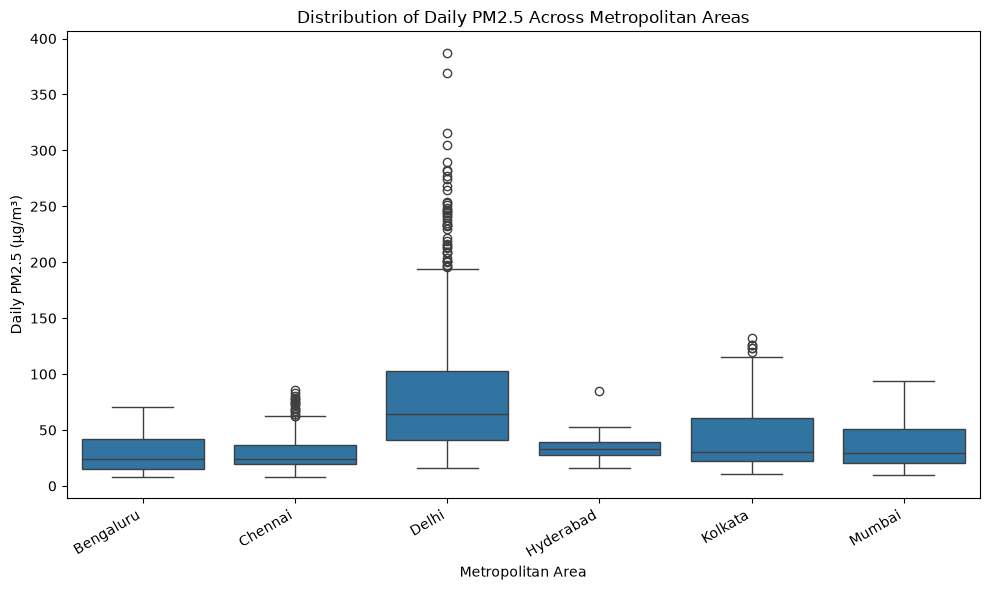

In [25]:
plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=city_day_balanced,
    x="metro",
    y="pm25_mean",
)

plt.xlabel(
    "Metropolitan Area"
)

plt.ylabel(
    "Daily PM2.5 (µg/m³)"
)

plt.title(
    "Distribution of Daily PM2.5 Across Metropolitan Areas"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_distribution_by_metro.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [26]:
mean_median_comparison = (
    city_day_balanced.groupby(
        "metro",
        observed=True,
    )
    .agg(
        mean_pm25=("pm25_mean", "mean"),
        median_pm25=("pm25_mean", "median"),
    )
)

mean_median_comparison["mean_minus_median"] = (
    mean_median_comparison["mean_pm25"]
    - mean_median_comparison["median_pm25"]
)

mean_median_comparison.sort_values(
    "median_pm25",
    ascending=False,
)

,mean_pm25,median_pm25,mean_minus_median
metro,,,
Delhi,88.08,64.11,23.98
Hyderabad,33.38,32.85,0.53
Kolkata,42.97,30.48,12.49
Mumbai,36.63,29.62,7.01
Chennai,30.07,24.13,5.94
Bengaluru,28.96,24.04,4.92


### Initial Interpretation

Daily PM2.5 concentrations differ substantially across the six metropolitan areas. Delhi shows the highest central tendency by a wide margin, with a median daily concentration of 64.11 µg/m³ and a mean of 88.08 µg/m³. Hyderabad has the second-highest median at 32.85 µg/m³, followed closely by Kolkata and Mumbai. Chennai and Bengaluru have the lowest median concentrations, at 24.13 and 24.04 µg/m³ respectively.

The distributions also differ considerably in variability. Delhi has both the largest interquartile range (62.02 µg/m³) and the largest standard deviation (68.34 µg/m³), indicating substantial day-to-day variation. Hyderabad is comparatively stable, with an interquartile range of only 11.26 µg/m³.

All six city distributions are positively skewed. The strongest right skew is observed in Delhi (1.63), Chennai (1.37), and Kolkata (1.14). The difference between mean and median is particularly large for Delhi and Kolkata, indicating that high-pollution episodes exert substantial influence on their arithmetic means. Consequently, medians and interquartile ranges are useful complements to means and standard deviations when describing the distributions.

These descriptive differences do not by themselves establish statistical significance. Because the balanced dataset contains measurements for all six metropolitan areas on the same 375 calendar dates, subsequent city-level hypothesis testing should account for the matched-by-date structure of the data.


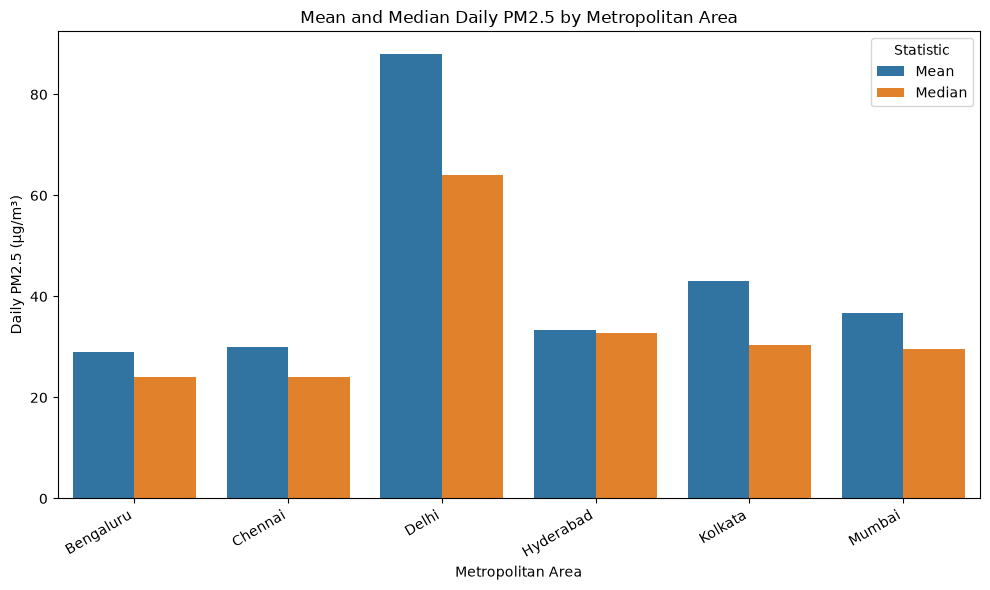

In [27]:
mean_median_plot = (
    mean_median_comparison
    .reset_index()
    .melt(
        id_vars="metro",
        value_vars=[
            "mean_pm25",
            "median_pm25",
        ],
        var_name="statistic",
        value_name="pm25",
    )
)

mean_median_plot["statistic"] = (
    mean_median_plot["statistic"]
    .map(
        {
            "mean_pm25": "Mean",
            "median_pm25": "Median",
        }
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=mean_median_plot,
    x="metro",
    y="pm25",
    hue="statistic",
)

plt.xlabel("Metropolitan Area")
plt.ylabel("Daily PM2.5 (µg/m³)")
plt.title("Mean and Median Daily PM2.5 by Metropolitan Area")

plt.xticks(
    rotation=30,
    ha="right",
)

plt.legend(
    title="Statistic"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_mean_median_by_metro.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Seasonal Variation

In [28]:
season_counts = (
    city_day_balanced[
        [
            "date_local",
            "season",
        ]
    ]
    .drop_duplicates()
    ["season"]
    .value_counts()
)

season_counts

season
Pre-monsoon          135
Southwest monsoon    128
Post-monsoon          74
Winter                38
Name: count, dtype: int64

In [29]:
season_descriptive = (
    city_day_balanced.groupby(
        "season",
        observed=True,
    )["pm25_mean"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
    )
)

season_descriptive["q1"] = (
    city_day_balanced.groupby(
        "season",
        observed=True,
    )["pm25_mean"]
    .quantile(0.25)
)

season_descriptive["q3"] = (
    city_day_balanced.groupby(
        "season",
        observed=True,
    )["pm25_mean"]
    .quantile(0.75)
)

season_descriptive["iqr"] = (
    season_descriptive["q3"]
    - season_descriptive["q1"]
)

season_descriptive

,count,mean,median,std,q1,q3,iqr
season,,,,,,,
Post-monsoon,444,73.81,51.41,64.51,38.70,80.05,41.36
Pre-monsoon,810,37.78,32.12,20.55,24.18,44.95,20.77
Southwest monsoon,768,25.17,22.81,10.97,17.73,29.57,11.83
Winter,228,65.04,55.17,34.75,40.38,79.28,38.91


In [30]:
city_season_summary = (
    city_day_balanced.groupby(
        [
            "metro",
            "season",
        ],
        observed=True,
    )["pm25_mean"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
    )
)

city_season_summary

count   mean  median   std
metro     season                                       
Bengaluru Post-monsoon          74  36.51   39.32 17.27
          Pre-monsoon          135  33.20   31.78 13.41
          Southwest monsoon    128  15.77   14.88  4.52
          Winter                38  43.62   46.53 11.53
Chennai   Post-monsoon          74  41.43   43.20 17.59
          Pre-monsoon          135  23.86   21.23  9.52
          Southwest monsoon    128  23.80   22.33  7.60
          Winter                38  51.10   49.25 16.50
Delhi     Post-monsoon          74 190.04  200.62 76.69
          Pre-monsoon          135  69.22   65.41 23.14
          Southwest monsoon    128  38.74   37.47 13.02
          Winter                38 122.77  112.90 36.55
Hyderabad Post-monsoon          74  40.26   41.90  7.53
          Pre-monsoon          135  33.96   32.57  6.99
          Southwest monsoon    128  27.12   27.13  6.10
          Winter                38  39.00   38.58  3.48
Kolkata   Post-monsoon          74  77.63   81.04 27.31
          Pre-monsoon          135  31.20   29.50 11.45
          Southwest monsoon    128  24.15   22.47  8.45
          Winter                38  80.67   79.25 17.98
Mumbai    Post-monsoon          74  56.97   58.61 18.65
          Pre-monsoon          135  35.26   32.73 16.91
          Southwest monsoon    128  21.46   19.78  8.72
          Winter                38  53.05   55.17 12.06

In [31]:
city_season_median = (
    city_day_balanced.pivot_table(
        index="metro",
        columns="season",
        values="pm25_mean",
        aggfunc="median",
        observed=True,
    )
)

city_season_median

season,Post-monsoon,Pre-monsoon,Southwest monsoon,Winter
metro,,,,
Bengaluru,39.32,31.78,14.88,46.53
Chennai,43.20,21.23,22.33,49.25
Delhi,200.62,65.41,37.47,112.90
Hyderabad,41.90,32.57,27.13,38.58
Kolkata,81.04,29.50,22.47,79.25
Mumbai,58.61,32.73,19.78,55.17


### Seasonal Interpretation

Seasonal differences in PM2.5 are evident across all six metropolitan areas, although the magnitude of the pattern varies substantially by city.

Delhi shows the strongest seasonal variation. Its median daily PM2.5 concentration is lowest during the Southwest monsoon at 37.47 µg/m³, rises to 65.41 µg/m³ during the pre-monsoon period, increases further to 112.90 µg/m³ during winter, and reaches 200.62 µg/m³ during the post-monsoon season.

Kolkata and Mumbai show a similar pattern, with substantially higher median concentrations during winter and the post-monsoon season than during the Southwest monsoon. Bengaluru and Chennai also exhibit lower concentrations during the monsoon period and higher concentrations during winter and post-monsoon months.

Hyderabad shows a comparatively smaller seasonal range, with median concentrations varying from 27.13 µg/m³ during the Southwest monsoon to 41.90 µg/m³ during the post-monsoon period.

Overall, the descriptive results suggest that seasonal effects are not uniform across metropolitan areas. Delhi exhibits particularly pronounced seasonal variation, while Hyderabad shows a more stable annual pattern. Formal statistical testing is required before concluding that these seasonal differences are statistically significant.

The seasonal comparisons should be interpreted with some caution because the study period does not contain an equal number of observations from every season. The analysis window begins in March 2025 and ends in August 2026, so winter and post-monsoon observations are drawn primarily from one annual cycle, whereas pre-monsoon and Southwest monsoon observations span portions of both 2025 and 2026. Seasonal descriptive statistics therefore characterize the available study period rather than a long-term climatological average.


In [32]:
SEASON_ORDER = [
    "Winter",
    "Pre-monsoon",
    "Southwest monsoon",
    "Post-monsoon",
]

city_season_median = (
    city_season_median[
        SEASON_ORDER
    ]
)

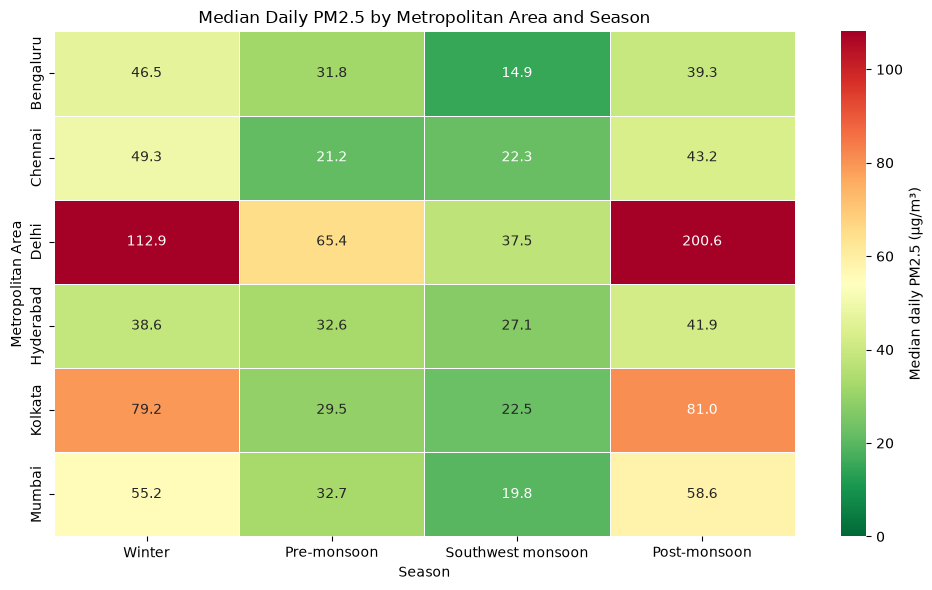

In [33]:
heatmap_values = city_season_median.to_numpy()

color_max = np.percentile(
    heatmap_values,
    95,
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    city_season_median,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=color_max,
    linewidths=0.5,
    cbar_kws={
        "label": "Median daily PM2.5 (µg/m³)"
    },
)

plt.xlabel("Season")
plt.ylabel("Metropolitan Area")

plt.title(
    "Median Daily PM2.5 by Metropolitan Area and Season"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_city_season_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The heatmap color scale is capped at the 95th percentile of the displayed city-season medians to improve visual differentiation among the lower-concentration cells. The annotated values show the actual medians; no observations were modified or truncated for analysis.

## 6. Comparison of March–August 2025 and March–August 2026

Because the study period contains only part of 2025 and part of 2026, a full-calendar-year comparison would not be appropriate. Instead, this analysis compares the common March–August period available in both years.

Restricting the comparison to identical calendar months reduces seasonal confounding and allows the two periods to be compared more directly.

In [34]:
year_comparison = city_day_balanced[
    city_day_balanced["month"].between(
        3,
        8,
    )
].copy()

year_comparison.groupby(
    [
        "year",
        "metro",
    ],
    observed=True,
)["date_local"].nunique().unstack(0)

year,2025,2026
metro,,
Bengaluru,133,109
Chennai,133,109
Delhi,133,109
Hyderabad,133,109
Kolkata,133,109
Mumbai,133,109


The comparable-period dataset contains 133 balanced March–August dates in 2025 and 109 in 2026. Therefore, the comparison controls for calendar months but is not a day-for-day paired comparison between years. Unequal date availability may contribute to some of the observed year-over-year differences, so these results are interpreted descriptively rather than as evidence of a causal or long-term trend.

In [35]:
year_city_summary = (
    year_comparison.groupby(
        [
            "metro",
            "year",
        ],
        observed=True,
    )["pm25_mean"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
    )
    .reset_index()
)

year_city_summary

,metro,year,count,mean,median,std
0,Bengaluru,2025,133,20.75,17.55,9.68
1,Bengaluru,2026,109,31.49,26.26,15.16
2,Chennai,2025,133,23.44,21.87,7.58
3,Chennai,2026,109,23.96,21.60,10.09
4,Delhi,2025,133,55.99,52.48,27.54
5,Delhi,2026,109,56.20,52.98,20.18
6,Hyderabad,2025,133,32.91,31.97,7.80
7,Hyderabad,2026,109,27.45,28.49,6.25
8,Kolkata,2025,133,30.55,28.94,11.99
9,Kolkata,2026,109,25.48,24.85,8.43


In [36]:
year_city_median = (
    year_city_summary.pivot(
        index="metro",
        columns="year",
        values="median",
    )
)

year_city_median["absolute_change"] = (
    year_city_median[2026]
    - year_city_median[2025]
)

year_city_median["percent_change"] = (
    year_city_median["absolute_change"]
    / year_city_median[2025]
    * 100
)

year_city_median.sort_values(
    "percent_change"
)

year,2025,2026,absolute_change,percent_change
metro,,,,
Mumbai,27.42,18.95,-8.47,-30.91
Kolkata,28.94,24.85,-4.09,-14.13
Hyderabad,31.97,28.49,-3.48,-10.89
Chennai,21.87,21.60,-0.27,-1.24
Delhi,52.48,52.98,0.49,0.94
Bengaluru,17.55,26.26,8.70,49.60


### March–August 2025 versus March–August 2026

The comparable March–August periods show different year-over-year patterns across the six metropolitan areas.

Mumbai exhibits the largest decrease in median daily PM2.5, falling from 27.42 µg/m³ in 2025 to 18.95 µg/m³ in 2026, a reduction of approximately 30.9%. Kolkata and Hyderabad also show decreases of approximately 14.1% and 10.9%, respectively. Chennai changes very little between the two periods, while Delhi's median concentration remains nearly unchanged.

Bengaluru shows the opposite pattern. Its median daily PM2.5 increases from 17.55 µg/m³ in March–August 2025 to 26.26 µg/m³ during the same months of 2026, an increase of approximately 49.6%.

These percentage changes describe the observed differences in the available data but do not by themselves establish a statistically significant trend or identify its cause. The comparison covers only two corresponding six-month periods and should therefore not be interpreted as evidence of a long-term improvement or deterioration in air quality.


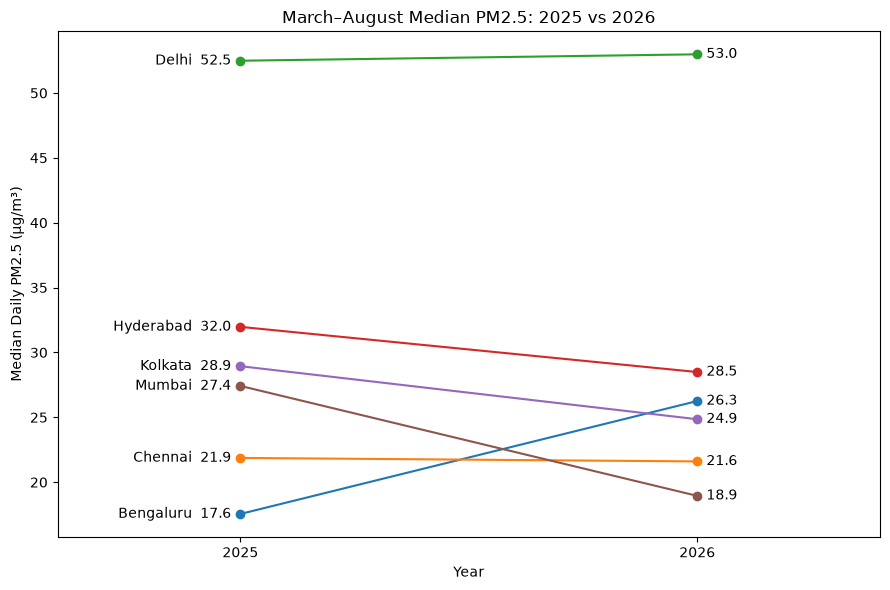

In [37]:
comparison_plot = (
    year_city_median[
        [2025, 2026]
    ]
    .reset_index()
)

plt.figure(figsize=(9, 6))

for _, row in comparison_plot.iterrows():
    plt.plot(
        [2025, 2026],
        [row[2025], row[2026]],
        marker="o",
    )

    plt.text(
        2024.98,
        row[2025],
        f"{row['metro']}  {row[2025]:.1f}",
        ha="right",
        va="center",
    )

    plt.text(
        2026.02,
        row[2026],
        f"{row[2026]:.1f}",
        ha="left",
        va="center",
    )

plt.xticks([2025, 2026])

plt.xlabel("Year")
plt.ylabel("Median Daily PM2.5 (µg/m³)")

plt.title(
    "March–August Median PM2.5: 2025 vs 2026"
)

plt.xlim(2024.6, 2026.4)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pm25_march_august_2025_2026.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The paired visualization highlights substantial differences in year-over-year direction across cities. Mumbai, Kolkata, and Hyderabad show lower median PM2.5 concentrations during March–August 2026, while Bengaluru shows a pronounced increase. Chennai and Delhi remain comparatively stable between the two periods.

### Comparison of Visual Models

The four visualizations emphasize different aspects of the PM2.5 data. The city-level boxplot provides the most complete view of the primary cross-city comparison because it displays differences in median concentration, dispersion, skewness, and extreme daily observations simultaneously. The mean-versus-median bar chart more directly illustrates the influence of right-skewed high-pollution episodes but does not show the underlying distribution. The seasonal heatmap is most useful for identifying how seasonal patterns differ across metropolitan areas, while the paired 2025–2026 plot provides the clearest representation of the direction and magnitude of change between the two comparable periods.

For the primary analytical question of how PM2.5 differs across metropolitan areas, the **boxplot provides the strongest single visual summary** because it shows both central tendency and variability rather than reducing each city to one summary statistic.

## 7. Statistical Comparison Across Metropolitan Areas

### Hypotheses

**H₀:** Daily PM2.5 concentrations do not systematically differ across the six metropolitan areas.

**H₁:** At least one metropolitan area exhibits systematically different daily PM2.5 concentrations.

The balanced city-day dataset contains observations for all six metropolitan areas on the same 375 dates. Because the observations are matched by date and several city distributions are strongly right-skewed, a Friedman test is used as a nonparametric repeated-measures comparison.

In [38]:
friedman_data = (
    city_day_balanced.pivot(
        index="date_local",
        columns="metro",
        values="pm25_mean",
    )
)

friedman_data.shape

(375, 6)

In [39]:
assert friedman_data.notna().all().all()

friedman_data.head()

metro,Bengaluru,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
date_local,,,,,,
2025-03-01,22.11,24.13,60.01,38.48,41.46,45.03
2025-03-02,20.61,18.02,52.08,29.99,44.22,43.70
2025-03-03,26.84,19.72,66.37,37.12,47.04,47.07
2025-03-04,31.20,17.41,53.61,46.58,41.99,51.12
2025-03-05,39.61,17.01,31.36,41.98,52.88,42.24


In [40]:
friedman_statistic, friedman_pvalue = stats.friedmanchisquare(
    *[
        friedman_data[column]
        for column in friedman_data.columns
    ]
)

print(
    f"Friedman statistic: "
    f"{friedman_statistic:.4f}"
)

print(
    f"p-value: "
    f"{friedman_pvalue:.6g}"
)

Friedman statistic: 767.5760
p-value: 1.1945e-163


In [41]:
n_dates = friedman_data.shape[0]
n_cities = friedman_data.shape[1]

kendalls_w = (
    friedman_statistic
    / (
        n_dates
        * (n_cities - 1)
    )
)

print(
    f"Kendall's W: "
    f"{kendalls_w:.4f}"
)

Kendall's W: 0.4094


### Friedman Test Results

The Friedman test found a statistically significant difference in daily PM2.5 concentrations across the six metropolitan areas, χ²(5) = 767.58, p < .001. Therefore, the null hypothesis that the cities have equivalent daily PM2.5 distributions is rejected.

Kendall's W was 0.409, indicating that the differences among cities are systematic rather than being explained only by random day-to-day variation. This result is consistent with the descriptive analysis, which showed particularly high concentrations in Delhi and substantial differences in both central tendency and variability across cities.

Because the omnibus Friedman test establishes only that at least one metropolitan area differs, pairwise post-hoc comparisons are required to identify which city pairs show statistically significant differences.


### Pairwise Post-Hoc Comparisons

Following the significant Friedman test, pairwise Wilcoxon signed-rank tests were performed between metropolitan areas using the matched daily observations. Because 15 pairwise comparisons are conducted, Holm's sequential correction is applied to control the family-wise error rate.

In [42]:
from itertools import combinations


def holm_adjust(p_values):
    """Apply Holm's sequential multiple-testing correction.

    Parameters
    ----------
    p_values : array-like
        Unadjusted p-values.

    Returns
    -------
    numpy.ndarray
        Holm-adjusted p-values in the original order.
    """
    p_values = np.asarray(p_values, dtype=float)

    order = np.argsort(p_values)
    sorted_p = p_values[order]

    n_tests = len(sorted_p)

    adjusted_sorted = np.empty(
        n_tests,
        dtype=float,
    )

    running_max = 0.0

    for rank, p_value in enumerate(sorted_p):
        adjusted = (
            (n_tests - rank)
            * p_value
        )

        running_max = max(
            running_max,
            adjusted,
        )

        adjusted_sorted[rank] = min(
            running_max,
            1.0,
        )

    adjusted = np.empty(
        n_tests,
        dtype=float,
    )

    adjusted[order] = adjusted_sorted

    return adjusted

In [43]:
pairwise_results = []

for city_a, city_b in combinations(
    friedman_data.columns,
    2,
):
    statistic, p_value = stats.wilcoxon(
        friedman_data[city_a],
        friedman_data[city_b],
        alternative="two-sided",
    )

    difference = (
        friedman_data[city_a]
        - friedman_data[city_b]
    )

    pairwise_results.append(
        {
            "city_a": city_a,
            "city_b": city_b,
            "wilcoxon_statistic": statistic,
            "p_value": p_value,
            "median_difference": difference.median(),
        }
    )

pairwise_results = pd.DataFrame(
    pairwise_results
)

pairwise_results[
    "p_value_holm"
] = holm_adjust(
    pairwise_results["p_value"]
)

pairwise_results[
    "significant"
] = (
    pairwise_results["p_value_holm"]
    < 0.05
)

pairwise_results.sort_values(
    "p_value_holm"
)

,city_a,city_b,wilcoxon_statistic,p_value,median_difference,p_value_holm,significant
1,Bengaluru,Delhi,198.00,0.00,-36.14,0.00,True
5,Chennai,Delhi,619.00,0.00,-37.96,0.00,True
10,Delhi,Kolkata,"1,105.00",0.00,28.25,0.00,True
9,Delhi,Hyderabad,"1,866.00",0.00,32.11,0.00,True
11,Delhi,Mumbai,"2,300.00",0.00,33.42,0.00,True
3,Bengaluru,Kolkata,"13,679.00",0.00,-9.96,0.00,True
7,Chennai,Kolkata,"14,351.00",0.00,-6.62,0.00,True
4,Bengaluru,Mumbai,"19,396.00",0.00,-6.32,0.00,True
6,Chennai,Hyderabad,"21,822.00",0.00,-5.86,0.00,True
2,Bengaluru,Hyderabad,"22,499.00",0.00,-5.47,0.00,True


In [44]:
print(
    f"Pairwise comparisons: "
    f"{len(pairwise_results)}"
)

print(
    f"Significant after Holm correction: "
    f"{pairwise_results['significant'].sum()}"
)

Pairwise comparisons: 15
Significant after Holm correction: 15


In [45]:
pairwise_display = (
    pairwise_results
    .sort_values("p_value_holm")
    .copy()
)

pairwise_display["p_value"] = (
    pairwise_display["p_value"]
    .map(lambda value: f"{value:.3e}")
)

pairwise_display["p_value_holm"] = (
    pairwise_display["p_value_holm"]
    .map(lambda value: f"{value:.3e}")
)

pairwise_display

,city_a,city_b,wilcoxon_statistic,p_value,median_difference,p_value_holm,significant
1,Bengaluru,Delhi,198.00,1.618e-62,-36.14,2.428e-61,True
5,Chennai,Delhi,619.00,4.551e-61,-37.96,6.372e-60,True
10,Delhi,Kolkata,"1,105.00",2.038e-59,28.25,2.650e-58,True
9,Delhi,Hyderabad,"1,866.00",7.050e-57,32.11,8.460e-56,True
11,Delhi,Mumbai,"2,300.00",1.865e-55,33.42,2.052e-54,True
3,Bengaluru,Kolkata,"13,679.00",9.677e-25,-9.96,9.677e-24,True
7,Chennai,Kolkata,"14,351.00",2.534e-23,-6.62,2.281e-22,True
4,Bengaluru,Mumbai,"19,396.00",4.430e-14,-6.32,3.544e-13,True
6,Chennai,Hyderabad,"21,822.00",1.629e-10,-5.86,1.141e-09,True
2,Bengaluru,Hyderabad,"22,499.00",1.276e-09,-5.47,7.654e-09,True


### Pairwise Post-Hoc Results

All 15 pairwise Wilcoxon signed-rank comparisons remained statistically significant after Holm correction at the .05 significance level.

The largest differences involve Delhi. On matched dates, Delhi's daily PM2.5 concentrations were typically substantially higher than those of the other metropolitan areas. The median paired difference was approximately 36.14 µg/m³ relative to Bengaluru, 37.96 µg/m³ relative to Chennai, 32.11 µg/m³ relative to Hyderabad, 28.25 µg/m³ relative to Kolkata, and 33.42 µg/m³ relative to Mumbai.

Several other city pairs were also statistically distinguishable but had much smaller differences. For example, the median paired difference between Hyderabad and Kolkata was only 0.68 µg/m³ in absolute magnitude, while the difference between Hyderabad and Mumbai was approximately 0.98 µg/m³. These results illustrate the distinction between **statistical significance and practical magnitude**: with 375 matched dates, relatively small but consistent differences can produce statistically significant results.

Taken together with the Friedman test and Kendall's W, the results provide strong evidence that daily PM2.5 patterns differ systematically across the six metropolitan areas, with Delhi exhibiting the most pronounced separation from the other cities.

## 8. Within-City Station Variability

PM2.5 concentrations also vary between monitoring stations within the same metropolitan area, indicating that a single city-wide value can obscure meaningful spatial differences.

In [46]:
station_summary = (
    daily.groupby(
        [
            "metro",
            "location_id",
            "station_name",
        ],
        observed=True,
    )["pm25_mean"]
    .agg(
        station_days="count",
        mean_pm25="mean",
        median_pm25="median",
        std_pm25="std",
    )
    .reset_index()
)

station_summary.head()

,metro,location_id,station_name,station_days,mean_pm25,median_pm25,std_pm25
0,Bengaluru,5548,"BTM Layout, Bengaluru - CPCB",293,27.29,21.55,13.59
1,Bengaluru,6973,"Jayanagar 5th Block, Bengaluru - KSPCB",366,33.05,29.12,18.12
2,Bengaluru,6975,"Silk Board, Bengaluru - KSPCB",337,32.79,27.79,17.36
3,Bengaluru,6983,"Hombegowda Nagar, Bengaluru - KSPCB",433,21.87,17.05,14.75
4,Bengaluru,6984,"Hebbal, Bengaluru - KSPCB",326,29.31,26.90,20.83


In [47]:
station_variability = (
    station_summary.groupby(
        "metro",
        observed=True,
    )["median_pm25"]
    .agg(
        stations="count",
        minimum_station_median="min",
        median_station_median="median",
        maximum_station_median="max",
        std_station_median="std",
    )
)

station_variability["station_median_range"] = (
    station_variability["maximum_station_median"]
    - station_variability["minimum_station_median"]
)

station_variability.sort_values(
    "station_median_range",
    ascending=False,
)

,stations,minimum_station_median,median_station_median,maximum_station_median,std_station_median,station_median_range
metro,,,,,,
Delhi,36,46.62,58.02,83.54,9.10,36.91
Hyderabad,13,15.35,30.83,43.39,7.24,28.04
Mumbai,20,16.56,22.60,38.51,6.01,21.95
Kolkata,6,20.19,29.01,39.92,7.59,19.73
Bengaluru,5,17.05,26.90,29.12,5.05,12.06
Chennai,6,20.73,22.33,27.45,2.48,6.73


### Within-City Variability Results

Delhi exhibits the greatest station-to-station variation. Median station-level PM2.5 concentrations range from 46.62 to 83.54 µg/m³, with a standard deviation of 9.10 µg/m³ across station medians. Hyderabad also shows substantial spatial variation, with station medians ranging from 15.35 to 43.39 µg/m³.

Mumbai and Kolkata display moderate within-city variability, while Bengaluru shows a smaller range. Chennai is the most spatially consistent of the six metropolitan areas in this dataset, with station medians ranging from 20.73 to 27.45 µg/m³ and a standard deviation of 2.48 µg/m³.

These results show that metropolitan averages should not be interpreted as representing identical exposure conditions throughout a city. However, comparisons of raw station ranges should be made cautiously because the number of monitoring stations differs considerably across metropolitan areas.


## 9. Sensitivity Analysis

A sensitivity analysis was conducted using a stricter cohort of 71 monitoring stations meeting a minimum overall measurement completeness threshold of 70%, compared with the 86-station primary cohort.

In [48]:
sensitivity_daily = (
    daily[
        daily["sensitivity_eligible"]
    ]
    .copy()
)

sensitivity_station_counts = (
    sensitivity_daily.groupby(
        "metro",
        observed=True,
    )["location_id"]
    .nunique()
    .rename("expected_stations")
    .reset_index()
)

sensitivity_station_counts

,metro,expected_stations
0,Bengaluru,3
1,Chennai,6
2,Delhi,33
3,Hyderabad,9
4,Kolkata,5
5,Mumbai,15


In [49]:
sensitivity_city_day = (
    sensitivity_daily.groupby(
        [
            "metro",
            "date_local",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        pm25_mean=("pm25_mean", "mean"),
        reporting_stations=("location_id", "nunique"),
    )
)

sensitivity_city_day = sensitivity_city_day.merge(
    sensitivity_station_counts,
    on="metro",
    how="left",
    validate="many_to_one",
)

sensitivity_city_day["station_coverage_pct"] = (
    sensitivity_city_day["reporting_stations"]
    / sensitivity_city_day["expected_stations"]
    * 100
)

In [50]:
sensitivity_city_day = (
    sensitivity_city_day[
        sensitivity_city_day["station_coverage_pct"] >= 50
    ]
    .copy()
)

In [51]:
sensitivity_cities_per_date = (
    sensitivity_city_day.groupby(
        "date_local"
    )["metro"]
    .nunique()
)

sensitivity_balanced_dates = (
    sensitivity_cities_per_date[
        sensitivity_cities_per_date == 6
    ].index
)

sensitivity_balanced = (
    sensitivity_city_day[
        sensitivity_city_day["date_local"]
        .isin(sensitivity_balanced_dates)
    ]
    .copy()
)

print(
    f"Sensitivity stations: "
    f"{sensitivity_daily['location_id'].nunique():,}"
)

print(
    f"Balanced sensitivity dates: "
    f"{len(sensitivity_balanced_dates):,}"
)

print(
    f"Balanced sensitivity city-days: "
    f"{len(sensitivity_balanced):,}"
)

Sensitivity stations: 71
Balanced sensitivity dates: 384
Balanced sensitivity city-days: 2,304


In [52]:
primary_medians = (
    city_day_balanced.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .median()
    .rename("primary_median")
)

sensitivity_medians = (
    sensitivity_balanced.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .median()
    .rename("sensitivity_median")
)

sensitivity_comparison = pd.concat(
    [
        primary_medians,
        sensitivity_medians,
    ],
    axis=1,
)

sensitivity_comparison["absolute_difference"] = (
    sensitivity_comparison["sensitivity_median"]
    - sensitivity_comparison["primary_median"]
)

sensitivity_comparison["percent_difference"] = (
    sensitivity_comparison["absolute_difference"]
    / sensitivity_comparison["primary_median"]
    * 100
)

sensitivity_comparison

,primary_median,sensitivity_median,absolute_difference,percent_difference
metro,,,,
Bengaluru,24.04,23.14,-0.90,-3.76
Chennai,24.13,24.14,0.01,0.04
Delhi,64.11,64.00,-0.11,-0.16
Hyderabad,32.85,33.75,0.91,2.76
Kolkata,30.48,31.89,1.41,4.63
Mumbai,29.62,23.74,-5.88,-19.86


In [53]:
sensitivity_friedman = (
    sensitivity_balanced.pivot(
        index="date_local",
        columns="metro",
        values="pm25_mean",
    )
)

sensitivity_statistic, sensitivity_pvalue = (
    stats.friedmanchisquare(
        *[
            sensitivity_friedman[column]
            for column in sensitivity_friedman.columns
        ]
    )
)

sensitivity_w = (
    sensitivity_statistic
    / (
        sensitivity_friedman.shape[0]
        * (
            sensitivity_friedman.shape[1]
            - 1
        )
    )
)

print(
    f"Friedman statistic: "
    f"{sensitivity_statistic:.4f}"
)

print(
    f"p-value: "
    f"{sensitivity_pvalue:.6g}"
)

print(
    f"Kendall's W: "
    f"{sensitivity_w:.4f}"
)

Friedman statistic: 838.5104
p-value: 5.38779e-179
Kendall's W: 0.4367


In [54]:
common_sensitivity_dates = (
    set(city_day_balanced["date_local"])
    & set(sensitivity_balanced["date_local"])
)

print(
    f"Common balanced dates: "
    f"{len(common_sensitivity_dates):,}"
)

Common balanced dates: 356


In [55]:
primary_common = (
    city_day_balanced[
        city_day_balanced["date_local"]
        .isin(common_sensitivity_dates)
    ]
    .copy()
)

sensitivity_common = (
    sensitivity_balanced[
        sensitivity_balanced["date_local"]
        .isin(common_sensitivity_dates)
    ]
    .copy()
)

assert (
    primary_common["date_local"].nunique()
    == sensitivity_common["date_local"].nunique()
)

assert len(primary_common) == len(sensitivity_common)

In [56]:
primary_common_medians = (
    primary_common.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .median()
    .rename("primary_median")
)

sensitivity_common_medians = (
    sensitivity_common.groupby(
        "metro",
        observed=True,
    )["pm25_mean"]
    .median()
    .rename("sensitivity_median")
)

common_date_comparison = pd.concat(
    [
        primary_common_medians,
        sensitivity_common_medians,
    ],
    axis=1,
)

common_date_comparison[
    "absolute_difference"
] = (
    common_date_comparison["sensitivity_median"]
    - common_date_comparison["primary_median"]
)

common_date_comparison[
    "percent_difference"
] = (
    common_date_comparison["absolute_difference"]
    / common_date_comparison["primary_median"]
    * 100
)

common_date_comparison

,primary_median,sensitivity_median,absolute_difference,percent_difference
metro,,,,
Bengaluru,24.77,23.70,-1.06,-4.30
Chennai,24.18,24.18,0.00,0.00
Delhi,65.20,65.08,-0.12,-0.18
Hyderabad,33.26,34.00,0.73,2.21
Kolkata,31.31,32.46,1.15,3.67
Mumbai,31.16,24.92,-6.24,-20.03


In [57]:
primary_common_matrix = (
    primary_common.pivot(
        index="date_local",
        columns="metro",
        values="pm25_mean",
    )
)

sensitivity_common_matrix = (
    sensitivity_common.pivot(
        index="date_local",
        columns="metro",
        values="pm25_mean",
    )
)

primary_common_stat, primary_common_p = (
    stats.friedmanchisquare(
        *[
            primary_common_matrix[column]
            for column in primary_common_matrix.columns
        ]
    )
)

sensitivity_common_stat, sensitivity_common_p = (
    stats.friedmanchisquare(
        *[
            sensitivity_common_matrix[column]
            for column in sensitivity_common_matrix.columns
        ]
    )
)

primary_common_w = (
    primary_common_stat
    / (
        len(primary_common_matrix)
        * (
            primary_common_matrix.shape[1]
            - 1
        )
    )
)

sensitivity_common_w = (
    sensitivity_common_stat
    / (
        len(sensitivity_common_matrix)
        * (
            sensitivity_common_matrix.shape[1]
            - 1
        )
    )
)

print(
    f"Primary common-date Kendall's W: "
    f"{primary_common_w:.4f}"
)

print(
    f"Sensitivity common-date Kendall's W: "
    f"{sensitivity_common_w:.4f}"
)

Primary common-date Kendall's W: 0.4067
Sensitivity common-date Kendall's W: 0.4343


### Sensitivity Analysis Results

To isolate the effect of station selection from differences in calendar availability, the primary and sensitivity cohorts were compared using the same 356 balanced dates. Results were highly consistent for five of the six metropolitan areas. Median PM2.5 differed by approximately 4.3% for Bengaluru, 0.0% for Chennai, 0.2% for Delhi, 2.2% for Hyderabad, and 3.7% for Kolkata.

Mumbai was the notable exception. Its median city-day PM2.5 decreased from 31.16 µg/m³ in the primary cohort to 24.92 µg/m³ in the stricter cohort, a difference of approximately 20.0%. This indicates that Mumbai's estimated city-level concentration is more sensitive to which monitoring stations satisfy the completeness requirement.

Despite this station-composition sensitivity for Mumbai, the overall cross-city statistical result remained stable. On the same 356 dates, Kendall's W was 0.407 for the primary cohort and 0.434 for the stricter cohort. The sensitivity analysis therefore supports the robustness of the main conclusion that PM2.5 concentrations differ systematically across metropolitan areas, while also demonstrating that individual city estimates can be affected by monitoring-station selection.


## 10. Conclusions

### Key Findings

This analysis examined daily PM2.5 patterns across six major Indian metropolitan areas between March 2025 and August 2026 and found substantial differences in concentration, variability, and seasonality. Delhi exhibited the highest concentrations and greatest temporal variability, while Bengaluru and Chennai generally recorded the lowest city-level medians. Descriptive seasonal patterns were particularly pronounced in Delhi, Kolkata, and Mumbai, with higher concentrations during winter and post-monsoon periods and lower concentrations during the Southwest monsoon. The March–August comparison showed substantial city-specific differences between 2025 and 2026, including a 30.9% decrease in Mumbai's median and a 49.6% increase in Bengaluru's, although these two-period observations should not be interpreted as long-term trends. The Friedman test confirmed systematic cross-city differences, χ²(5) = 767.58, p < .001, with Kendall's W = 0.409, and all 15 pairwise Wilcoxon comparisons remained significant after Holm correction. A key analytical challenge was unequal monitoring coverage and station composition; balanced-date filtering and sensitivity analysis reduced this concern, although Mumbai remained notably sensitive to station selection.


### Limitations

Several limitations should be considered when interpreting these results.

First, monitoring stations are not distributed uniformly across metropolitan areas. The analysis reduces this imbalance by aggregating station measurements to city-day observations and imposing minimum station-coverage requirements, but the monitoring network should not be interpreted as a spatially random sample of each metropolitan area.

Second, measurement availability is incomplete. Station-days were required to contain at least 18 valid hourly observations, and city-days were required to include at least 50% of eligible stations. These requirements improve data completeness but may introduce bias if missing observations are systematically associated with particular pollution conditions.

Daily PM2.5 observations may also exhibit temporal autocorrelation, meaning concentrations on adjacent days may not be statistically independent. The Friedman and Wilcoxon procedures used in this analysis account for matching across cities on the same dates but do not explicitly model serial dependence between successive dates. The resulting p-values should therefore be interpreted as conventional matched-sample inference rather than inference from a time-series model.

Third, the analysis period covers approximately 18 months rather than multiple complete annual cycles. Winter and post-monsoon observations are therefore less temporally replicated than the pre-monsoon and Southwest monsoon periods. Seasonal findings characterize the available study period rather than long-term climatological behavior.

Fourth, the March–August 2025 and March–August 2026 comparison represents only two corresponding six-month periods. Differences between these periods cannot establish a long-term trend or determine whether changes were caused by policy, weather, emissions, monitoring-network changes, or other factors.

The upper cleaning threshold of 1,000 µg/m³ was an empirical, project-specific anomaly-screening rule based on the observed data-quality patterns rather than a universal regulatory validity threshold. Consequently, rare valid extreme measurements could potentially have been excluded, while less obvious anomalous measurements below the threshold could remain.

Finally, sensitivity analysis showed that Mumbai's estimated median concentration changed materially when the stricter station-completeness cohort was used. This demonstrates that city-level estimates can depend on monitoring-station composition and should be interpreted in the context of the underlying monitoring network.


### Statistical and Practical Significance

The inferential results provide strong evidence that PM2.5 distributions differ across metropolitan areas, but statistical significance should not be interpreted as equivalent to practical importance. Some matched city pairs differed substantially, particularly comparisons involving Delhi, whereas other statistically significant comparisons had median paired differences of less than 1 µg/m³. Reporting the Friedman effect size, paired differences, descriptive statistics, and sensitivity analysis alongside p-values provides a more complete interpretation of the observed differences.
